# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [2]:
# 피어슨 상관계수 : 두 숫자형 변수의 선형 관계를 -1 ~ +1로 나타내는 지표
# -> 한 달의 광고비와 그 달 매출을 한 쌍으로 묶어 선형 관계로 표현

# 양의 상관 : 같은 방향으로 움직임
# -> +방향이면 같이 +방향으로
# 공부를 많이하면 많이 할수록 성적이 증가함

# 음의 상관 : 같은방향으로 움직임
# -> +방향인데 -방향으로 반대로 움직임
# 광고비 투자를 많이 했지만 매출은 감소하는 경향

# 결정계수(R²) : R²이 0.95면 이 모델은 이 데이터에 대한 설명력을 95%정도 가지고 있다.
# 1에 가까울수록 좋음

# 상관관계 : 두 변수가 함께 달라지는 통계적 관계
# -> 광고 노출이 많은 날 주문도 많다라는 것은 상관관계가 있다라고 볼 수 있음

# 인과관계 : 어떤 조건을 바꿨을 때, 그 변화때문에 결과가 달라지는 관계
# -> 다른 조건을 같게 설정한 뒤 광고 노출을 기존과 다르게 하여 주문량이 달라지는 것을 알아보는 것


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing.CSV")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
-> r값이 양수값이고 절대값이 0.71이므로 비교적 강한 양의 상관관계

- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
-> p-value가 0.05보다 작으므로 상관계수가 0일 것이라는 귀무가설을 기각한다.
-> 즉 두 변수는 통계적으로 유의함

- $r^2$은 이 관계에서 무엇을 의미하나요?
-> 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 접합하여 결정계수 r^2이 약 0.50이다.
-> 즉, 생활면적을 이용한 직선모형이 이 자료의 가격 변동을 약 50.2%를 설명한다.

- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
-> 아닙니다. 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다.


원본 행 수: 1460, 결측치 제거 후 행 수: 1460

피어슨 상관계수(r): 0.7086
p-value: 4.5180e-223
r^2: 0.5021


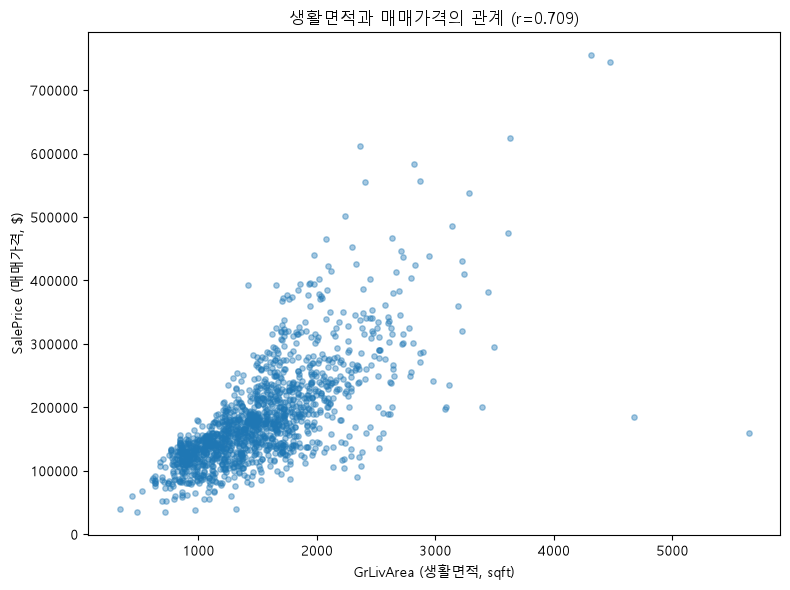

In [6]:
# 여기에 코드를 작성하세요.
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
# 1. 결측치 제거한 분석용 데이터
analysis_df = df[['GrLivArea', 'SalePrice']].dropna()
print(f"원본 행 수: {len(df)}, 결측치 제거 후 행 수: {len(analysis_df)}")

# 2. 피어슨 상관계수와 p-value
r, p_value = stats.pearsonr(analysis_df['GrLivArea'], analysis_df['SalePrice'])
print(f"\n피어슨 상관계수(r): {r:.4f}")
print(f"p-value: {p_value:.4e}")

# 3. r^2 계산
r_squared = r ** 2
print(f"r^2: {r_squared:.4f}")

# 4. 산점도 (축 이름, 제목 포함)
plt.figure(figsize=(8, 6))
plt.scatter(analysis_df['GrLivArea'], analysis_df['SalePrice'], alpha=0.4, s=15)
plt.xlabel('GrLivArea (생활면적, sqft)')
plt.ylabel('SalePrice (매매가격, $)')
plt.title(f'생활면적과 매매가격의 관계 (r={r:.3f})')
plt.tight_layout()
plt.show()

---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
-> r 0.71 -> 0.26으로 감소, p-value는 0.05 미만에서 0.06으로 증가했다.
-> 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경

- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
-> 요약값만 보면 변화의 원인을 한 눈에 파악하기 어려움
-> 산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
-> 이 점은 이상치도 한 눈에 파악하기 쉽다는 것을 알려줌

- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
-> 피어슨 r은 직선형태의 관계를 요약함
-> u자형 그래프의 왼쪽과 오른쪽은 서로 반대방향의 선형 움직임을 보이기 때문에 0에 가까움

- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
-> 아닙니다. r ≈ 0은 선형관계가 거의 없다는 뜻, 비선형 관계는 존재할 수 있다.


[이상치 추가 전] r = 0.7059, p-value = 1.0263e-08
[이상치 추가 후] r = 0.2602, p-value = 6.5137e-02


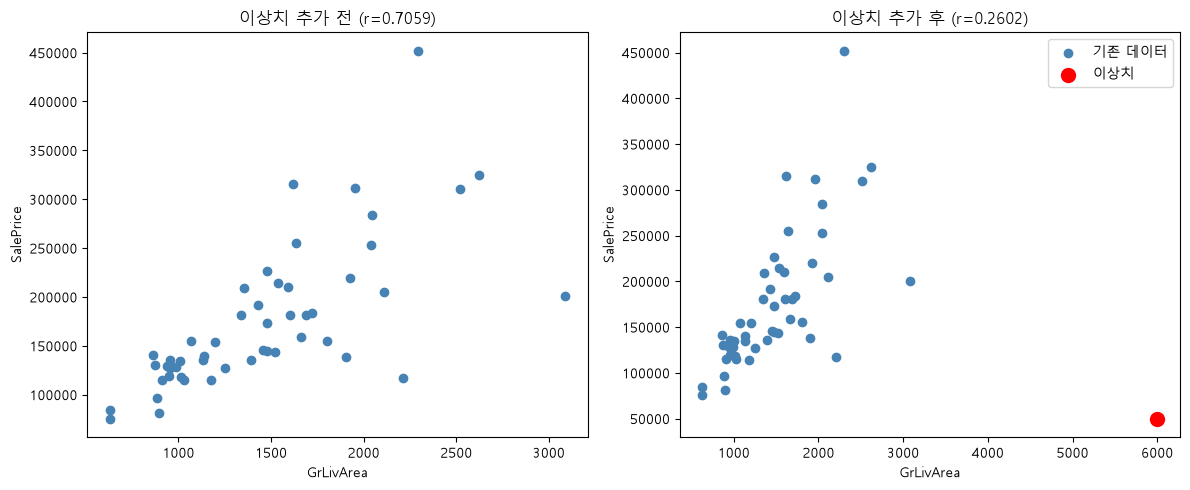

r = 0.0000, p-value = 1.0000


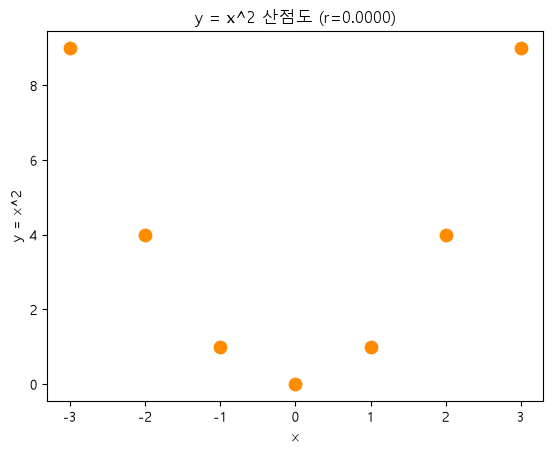

In [9]:
# 여기에 코드를 작성하세요.
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 1. 표본 50개 추출
sample = df[["GrLivArea", "SalePrice"]].dropna().sample(n=50, random_state=42).copy()

# 2. 이상치 추가 전 r, p-value
r_before, p_before = stats.pearsonr(sample["GrLivArea"], sample["SalePrice"])
print(f"[이상치 추가 전] r = {r_before:.4f}, p-value = {p_before:.4e}")

# 3. 이상치 추가 (원본 df는 그대로 두고, sample의 복사본에만 추가)
outlier = pd.DataFrame({"GrLivArea": [6000], "SalePrice": [50000]})
sample_with_outlier = pd.concat([sample, outlier], ignore_index=True)

# 4. 이상치 추가 후 r, p-value
r_after, p_after = stats.pearsonr(sample_with_outlier["GrLivArea"], sample_with_outlier["SalePrice"])
print(f"[이상치 추가 후] r = {r_after:.4f}, p-value = {p_after:.4e}")

# 5. 산점도 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(sample["GrLivArea"], sample["SalePrice"], color="steelblue")
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[0].set_title(f"이상치 추가 전 (r={r_before:.4f})")

axes[1].scatter(sample_with_outlier["GrLivArea"][:-1], sample_with_outlier["SalePrice"][:-1],
                color="steelblue", label="기존 데이터")
axes[1].scatter(outlier["GrLivArea"], outlier["SalePrice"], color="red", s=100, label="이상치")
axes[1].set_xlabel("GrLivArea")
axes[1].set_ylabel("SalePrice")
axes[1].set_title(f"이상치 추가 후 (r={r_after:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

r, p = stats.pearsonr(x, y)
print(f"r = {r:.4f}, p-value = {p:.4f}")

plt.scatter(x, y, color="darkorange", s=80)
plt.xlabel("x")
plt.ylabel("y = x^2")
plt.title(f"y = x^2 산점도 (r={r:.4f})")
plt.show()

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

r=0.26으로 약한 양의 상관관계가 있으며(1), p-value가 0.05보다 작아 통계적으로 유의미한 근거는 있으나 설명력(r^2)이 6.9% 정도만 설명을 하는 약한 관계를 띄고 있어 같은 의미는 아닌 것으로 해석된다(2). 대지면적이 넓어지면 매매가격이 오른다는 인과결론도 낼 수 없다. p-value가 0.05보다 작아 귀무가설을 기각하지만 이 의미가 연관이 있다는 통계적 근거만 있을 뿐 인과관계를 주장할 수 있는 근거로는 부족하기 떄문이다(3). 혼란변수는 '지역의 위치'나 '인프라'에 따라서도 달라질 수 있닫(4). 피어슨 상관계수가 0에 가깝다고 해서 아무 관계도 없다고 판단할 수 없다. 피어슨 상관계수가 반영하지 못하는 비선형 관계가 나타날 수 있기 때문이다.(5)



r = 0.2638
p-value = 1.1231e-24
r^2 = 0.0696


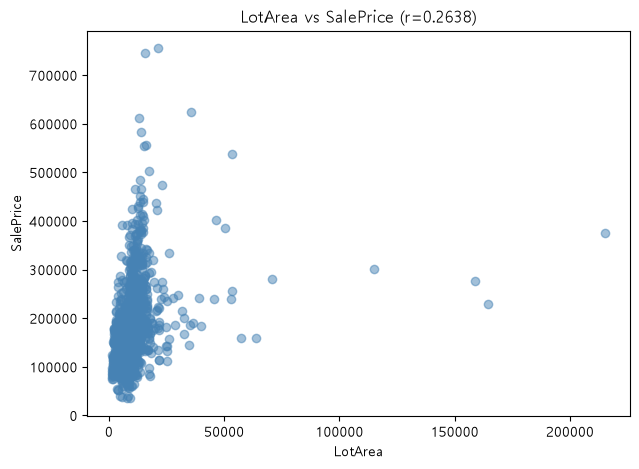

유의수준 0.05에서 유의함: True


In [10]:
# 여기에 코드를 작성하세요.

# 1. 피어슨 상관계수, p-value, r^2
data = df[["LotArea", "SalePrice"]].dropna()
r, p = stats.pearsonr(data["LotArea"], data["SalePrice"])
r_squared = r ** 2

print(f"r = {r:.4f}")
print(f"p-value = {p:.4e}")
print(f"r^2 = {r_squared:.4f}")

# 2. 산점도
plt.figure(figsize=(7, 5))
plt.scatter(data["LotArea"], data["SalePrice"], alpha=0.5, color="steelblue")
plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.title(f"LotArea vs SalePrice (r={r:.4f})")
plt.show()

# 3. 유의성 판단
alpha = 0.05
is_significant = p < alpha
print(f"유의수준 0.05에서 유의함: {is_significant}")

---

## 실습 마무리

- 어떤 문제가 있었는가?
-> 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움

- 어떻게 개선했는가?
-> r, r^2, p-value, 산점도, 이상치 유무

- 무엇을 근거로 개선되었다고 판단했는가?
- 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인함
-> 본 데이터의 이상피를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.